In [59]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# Import data
df = pd.read_csv(Path('data/processed') / 'panel_data.csv')

In [61]:
# Take a look at dataframe
df.describe()

,year,log_gdppc_growth,rgdpe,rgdp_pc,tariff,tariff_import_weighted,tariff_lag1,tariff_lag2,trade_gdp,hc,csh_i,csh_g,pl_i,pop_growth
count,2632.000000,2632.000000,2.632000e+03,2632.000000,2632.000000,2632.000000,2536.000000,2439.000000,2632.000000,2534.000000,2632.000000,2632.000000,2632.000000,2632.000000
mean,2009.576748,2.844245,9.746096e+05,25014.951633,6.425027,7.086636,7.124810,7.170094,84.833857,2.638506,0.233923,0.178565,0.558641,0.012977
std,8.404775,6.266000,2.851874e+06,24554.715681,6.949188,5.735639,5.784682,5.833274,54.340970,0.656939,0.079260,0.062922,1.493052,0.014784
min,1988.000000,-51.979697,1.994118e+03,885.714702,0.000000,0.000000,0.000000,0.000000,14.390878,1.041401,0.000193,0.044603,0.109506,-0.084230
25%,2003.000000,0.029627,3.853738e+04,6270.953979,1.690000,2.871166,2.886876,2.922482,51.670135,2.163163,0.181609,0.132291,0.372764,0.004399
50%,2010.000000,2.834718,1.591143e+05,15841.230781,4.390000,5.766441,5.775847,5.811107,71.637425,2.707596,0.229999,0.172470,0.466665,0.011504
75%,2017.000000,5.866145,5.883336e+05,40468.844396,9.132500,10.345080,10.352142,10.387898,102.139424,3.162738,0.278625,0.215484,0.599047,0.020162
max,2023.000000,45.656311,3.059032e+07,209045.757942,107.130000,88.817845,88.817845,88.817845,437.326715,3.941190,0.639970,0.471648,72.267404,0.217003


In [62]:
def line_plot(df, variable):
    '''Plot the average of a variable by year over the time period.'''
    
    # Ensure variable is numeric
    df[variable] = pd.to_numeric(df[variable], errors='coerce')
    
    # Group by year and compute average
    year_avg = df.groupby('year')[variable].mean()

    # Create line plot
    plt.figure(figsize=(6, 3))
    plt.plot(year_avg.index, year_avg.values)
    plt.xlabel('Year')
    plt.ylabel(f'Average {variable}')
    plt.title(f'Average {variable} over time')
    plt.show()

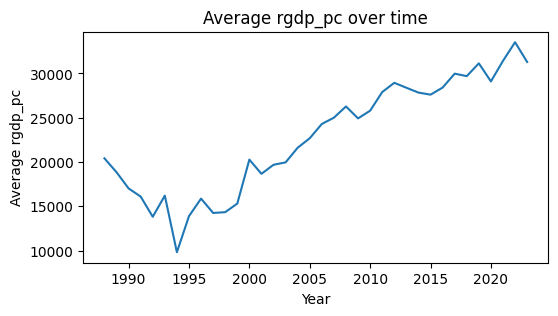

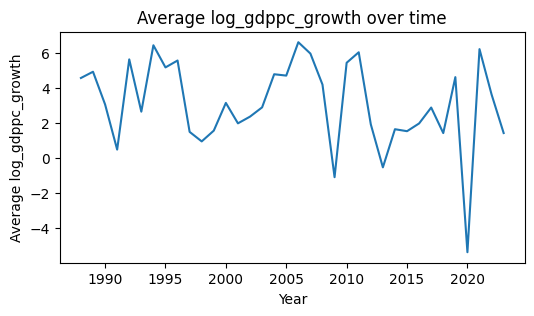

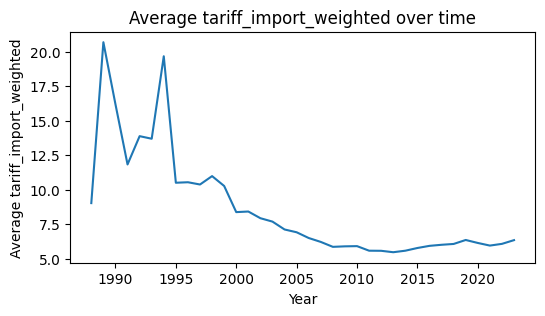

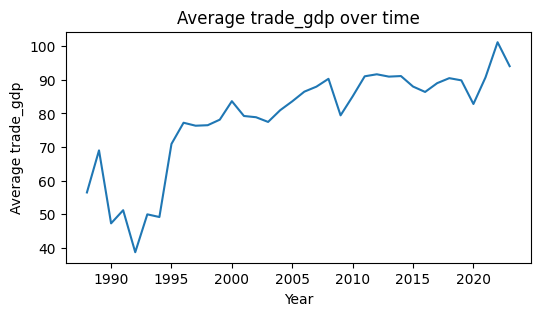

In [63]:
# Make plots of variables
line_plot(df, 'rgdp_pc')
line_plot(df, 'log_gdppc_growth')
line_plot(df, 'tariff_import_weighted')
line_plot(df, 'trade_gdp')

In [64]:
def scatter_plot(df, x_var, y_var, x_cap_quantile = 1, y_cap_quantile = 1):
    '''Create a scatter plot of two variables.'''
    
    # Ensure variable is numeric 
    df[x_var] = pd.to_numeric(df[x_var], errors='coerce')
    df[y_var] = pd.to_numeric(df[y_var], errors='coerce')


    # Optionally cap axes at a high quantile to reduce impact of extreme outliers
    if x_cap_quantile is not None:
        x_cap = df[x_var].quantile(x_cap_quantile)
        df = df[df[x_var] <= x_cap]

    if y_cap_quantile is not None:
        y_cap = df[y_var].quantile(y_cap_quantile)
        df = df[df[y_var] <= y_cap]

    # Create scatter plot
    plt.figure(figsize=(6, 3))
    plt.scatter(df[x_var], df[y_var])
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(f'{y_var} vs {x_var}')
    plt.show()

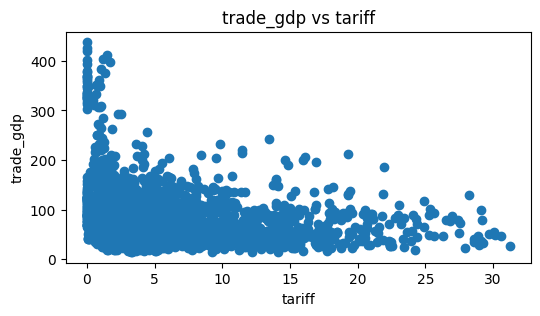

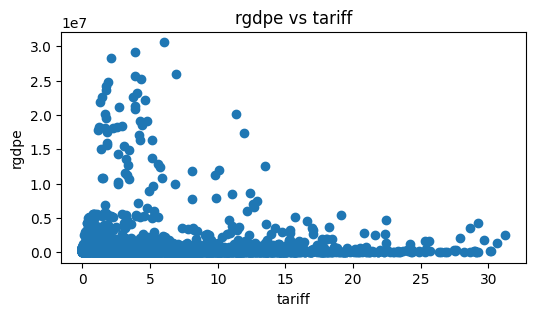

In [65]:
# Create scatter plot with tariffs and trade as % of GDP
scatter_plot(df, 'tariff', 'trade_gdp', 0.99)

# Create scatter plot with real tariffs and trade as % of GDP
scatter_plot(df, 'tariff', 'rgdpe', 0.99)

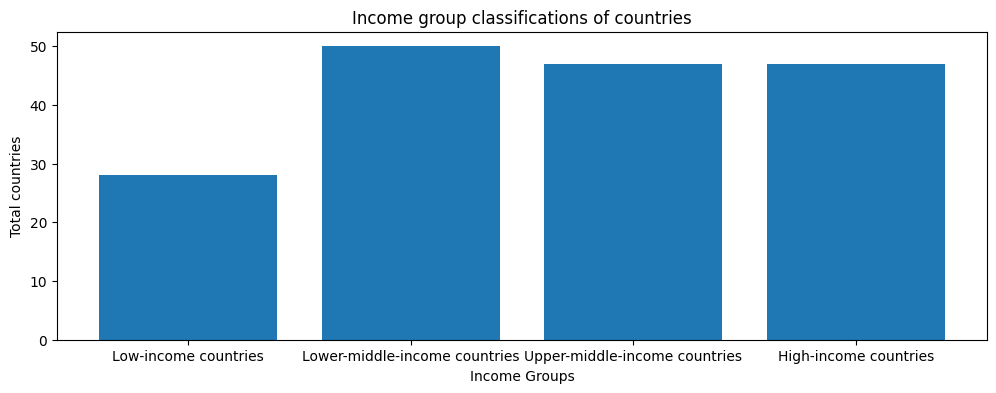

In [66]:
# Create bar plot of income group distribution 
# (includes countries whose classification changes throughout time)
unique_countries = df[['country', 'income_group']].drop_duplicates()

# Define income group order from low to high
income_order = [
    'Low-income countries',
    'Lower-middle-income countries',
    'Upper-middle-income countries',
    'High-income countries'
]

# Count countries per income group and reindex to enforce order
counts = (
    unique_countries['income_group']
    .value_counts()
    .reindex(income_order)
)

# Plot
plt.figure(figsize=(12, 4))
plt.bar(counts.index, counts.values)
plt.xlabel('Income Groups')
plt.ylabel('Total countries')
plt.title('Income group classifications of countries')
plt.show()

In [71]:
def plot_by_income_group(df, variable, ylabel, title):
    """Plot the average of a variable by income group over time."""
    income_order = [
        'Low-income countries',
        'Lower-middle-income countries',
        'Upper-middle-income countries',
        'High-income countries'
    ]
    
    grouped = (
        df
        .dropna(subset=[variable, 'income_group'])
        .groupby(['income_group', 'year'])[variable]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(9, 5))
    for group in income_order:
        subset = grouped[grouped['income_group'] == group]
        if not subset.empty:
            plt.plot(subset['year'], subset[variable], label=group)

    plt.xlabel('Year')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title='Income group')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

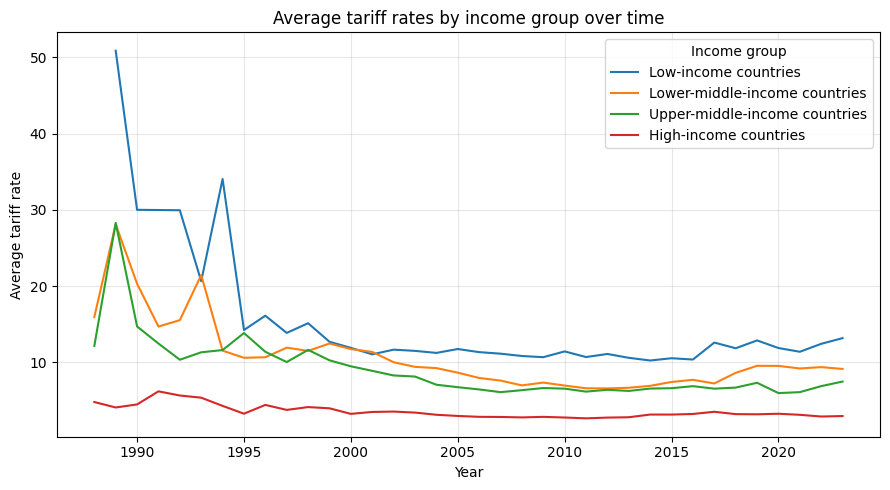

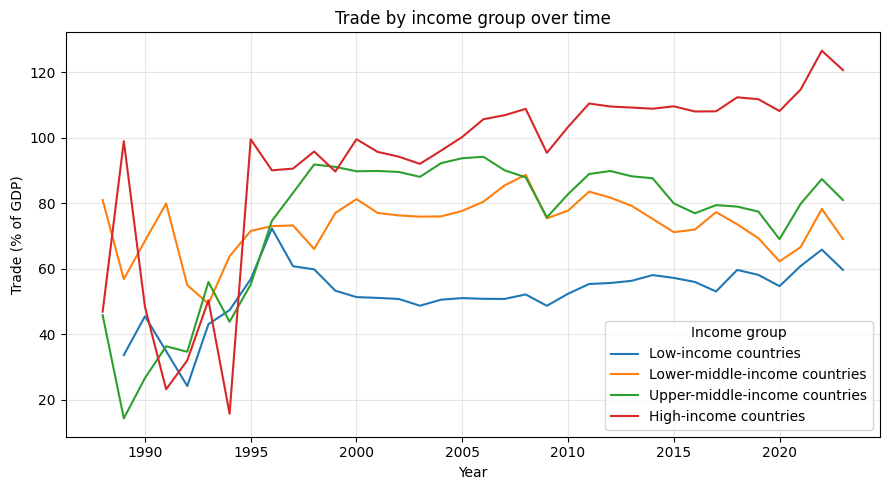

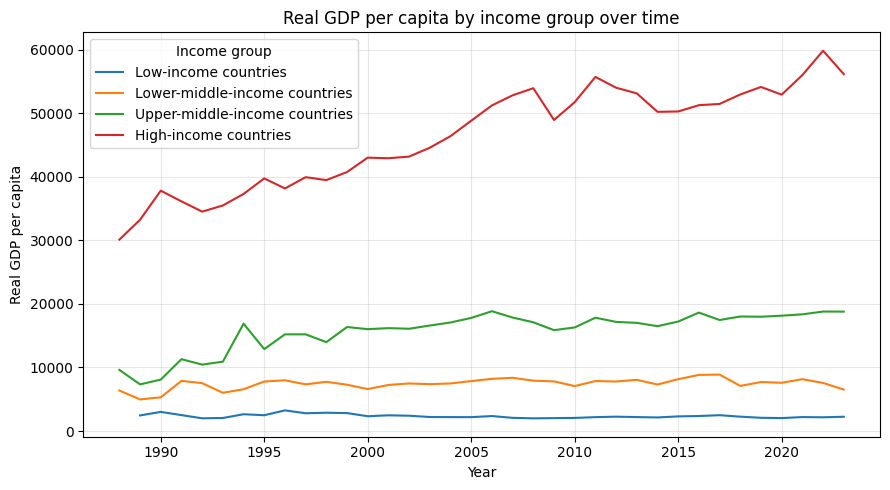

In [ ]:
# Create line plots of variables by income group
plot_by_income_group(df, 'tariff_import_weighted', 'Average tariff rate', 
                     'Average tariff rates by income group over time')

plot_by_income_group(df, 'trade_gdp', 'Trade (% of GDP)', 
                     'Trade by income group over time')

plot_by_income_group(df, 'rgdp_pc', 'Real GDP per capita', 
                     'Real GDP per capita by income group over time')